In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\ogbid\OneDrive\Documents\py_Projects\House_ICA\data\1553768847-housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
%pip install missingno
import missingno as msno

def data_exploration(df):
    
    msno.matrix(df)
    #plt.show()
    #msno.heatmap(df)
    #plt.figure(figsize=(10,5))
    plt.show()
    
    sns.scatterplot(data=df, x = 'longitude', y = 'latitude', hue='median_house_value', alpha=0.5)
    #plt.figure(figsize=(2,32))
    plt.title ('Spacial Distribution of MedianHouseValue')
    plt.show()

    sns.countplot(data = df, x='ocean_proximity', palette='Set2')
    plt.show()

    df.groupby('ocean_proximity')['median_income'].mean().plot(kind='bar')
    plt.show()

    df['housing_median_age'].hist(figsize=(5,5))
    plt.show()
    sns.histplot(data = df, x = 'housing_median_age', bins=50, kde = True,)
    plt.title('Housing MedianAge Distribution')
    plt.xlabel('Median Age')
    plt.ylabel('Frequency')
    plt.show()

    df['median_income'].hist(figsize=(10,5))
    plt.show()
    sns.histplot(data = df, x = 'median_income', bins=50, kde = True,)
    plt.title('Median Income Distribution')
    plt.xlabel('Median Income')
    plt.ylabel('Frequency')
    plt.show()

    sns.scatterplot(data=df, x = 'longitude', y = 'latitude', hue='total_bedrooms', alpha=0.5, )
    #plt.title ('Spacial Distribution of MedianHouseValue')
    plt.show()


    df_1 = df[['households', 'median_income', 'median_house_value', 'ocean_proximity', 'total_bedrooms']]
    sns.pairplot(data = df_1, kind='scatter', diag_kind='hist')
    plt.show()

    #sns.pairplot(data=df, kind=)

Note: you may need to restart the kernel to use updated packages.


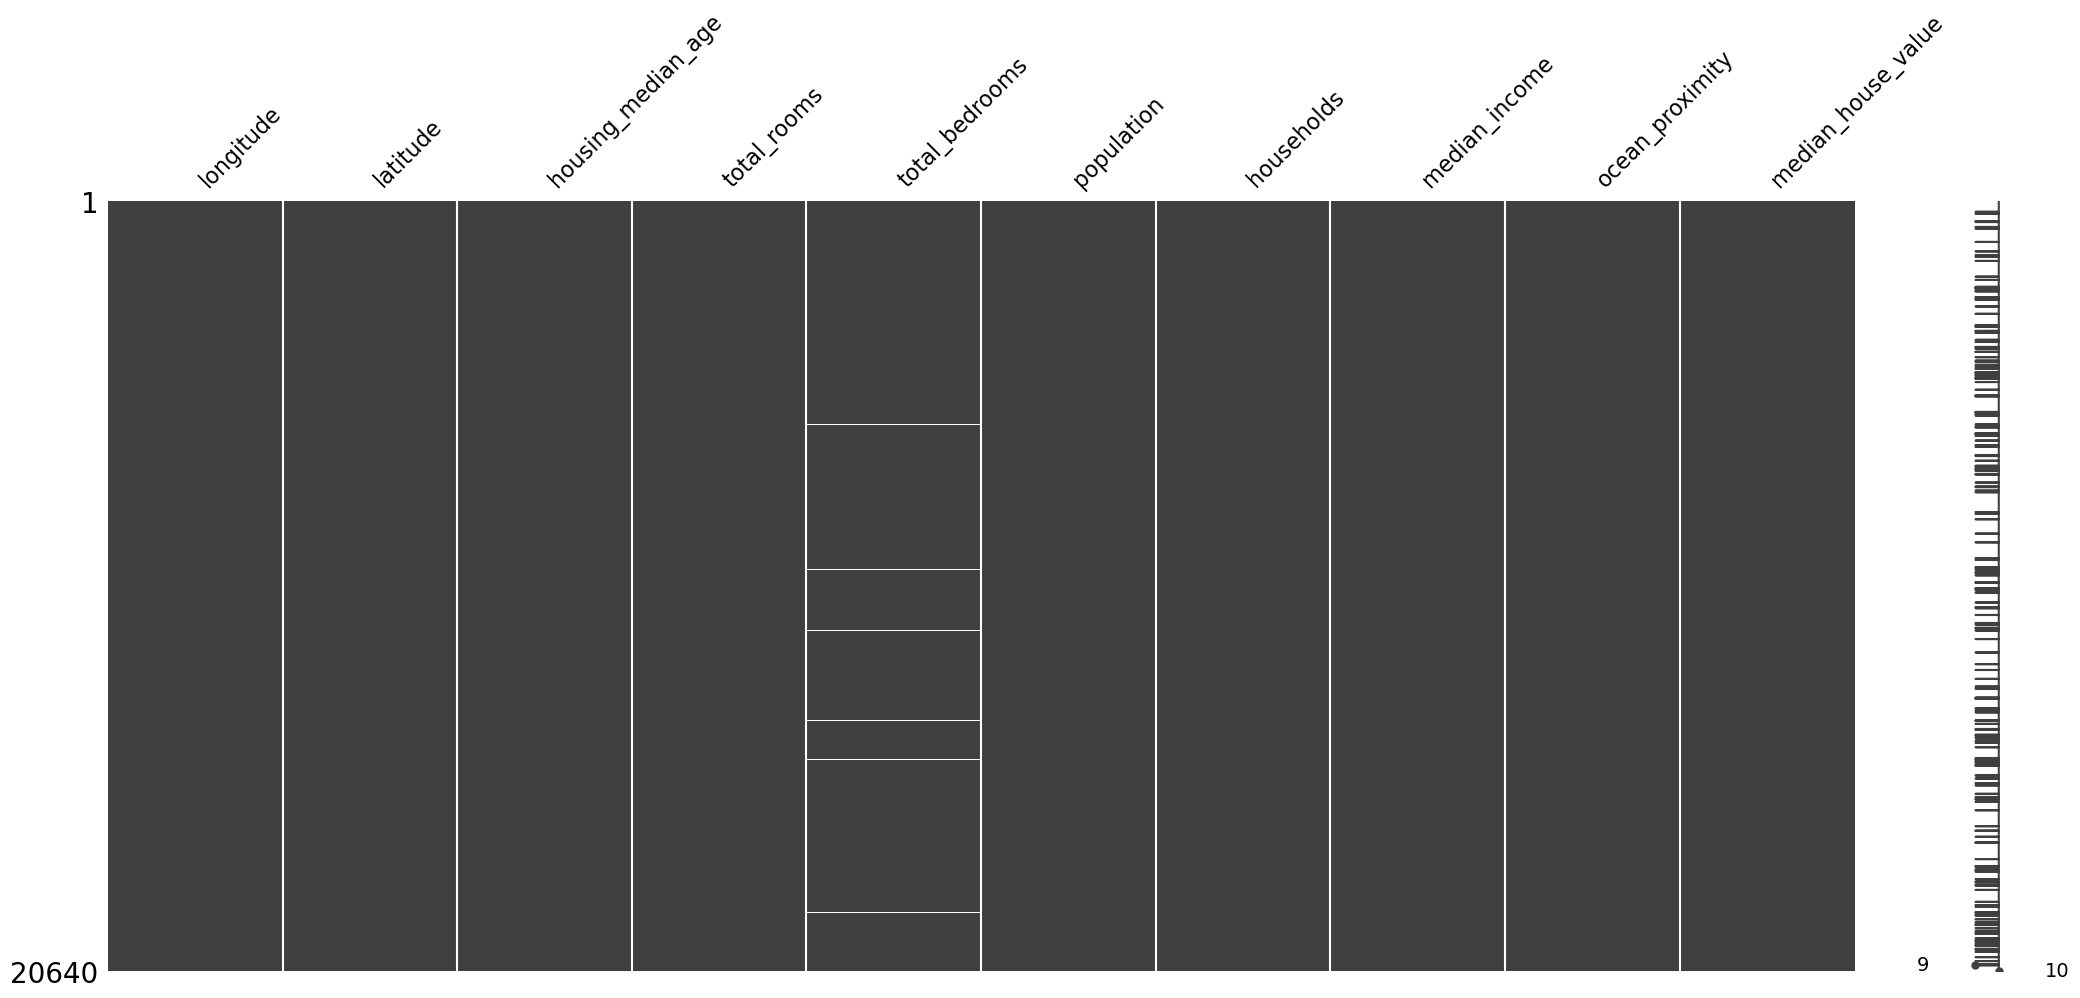

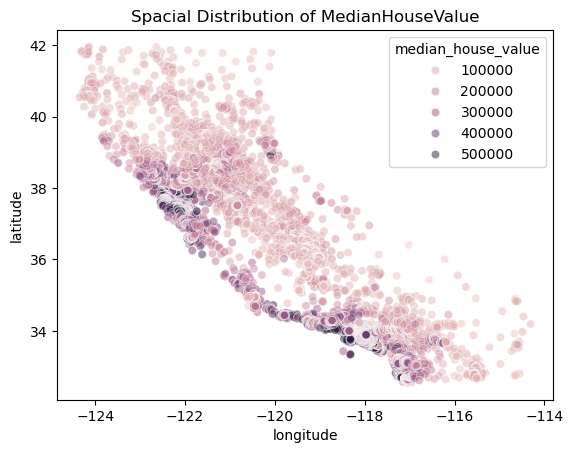

C:\Users\ogbid\AppData\Local\Temp\ipykernel_16972\960783942.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x='ocean_proximity', palette='Set2')


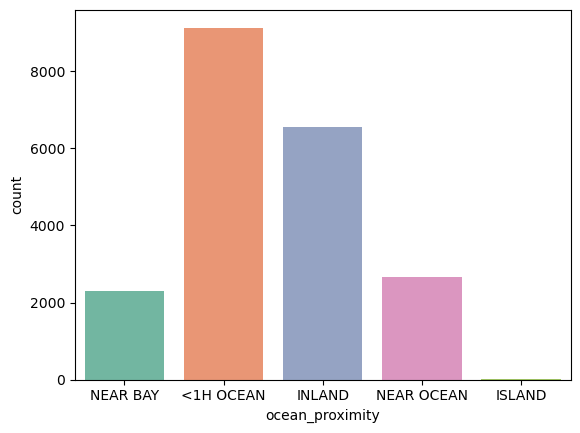

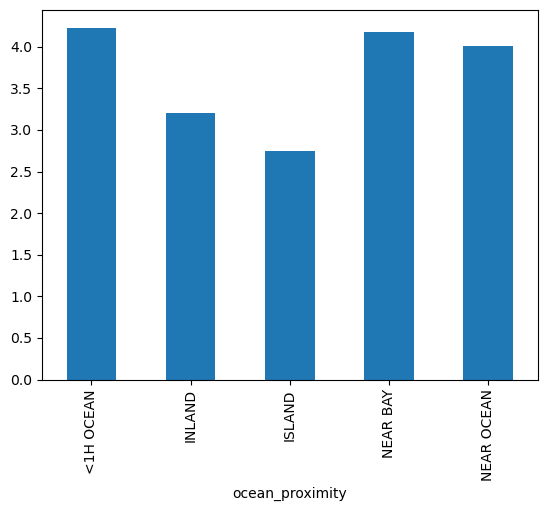

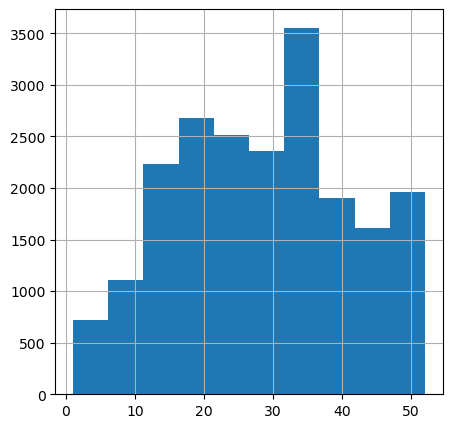

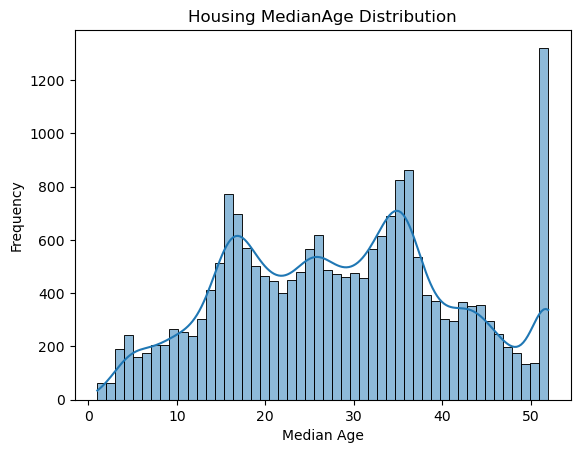

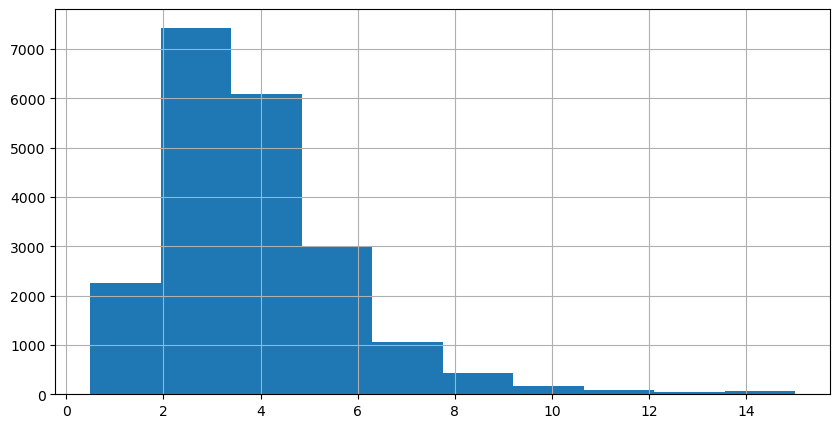

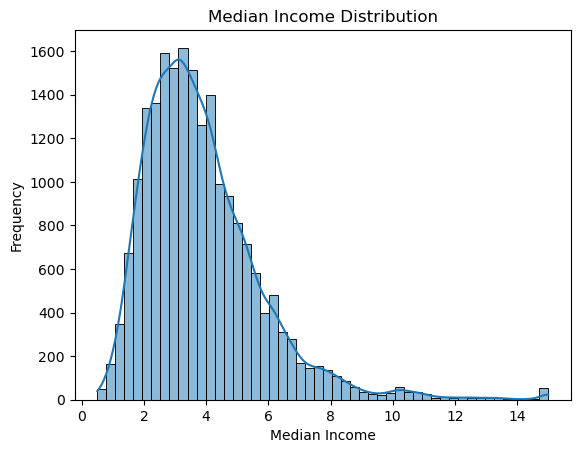

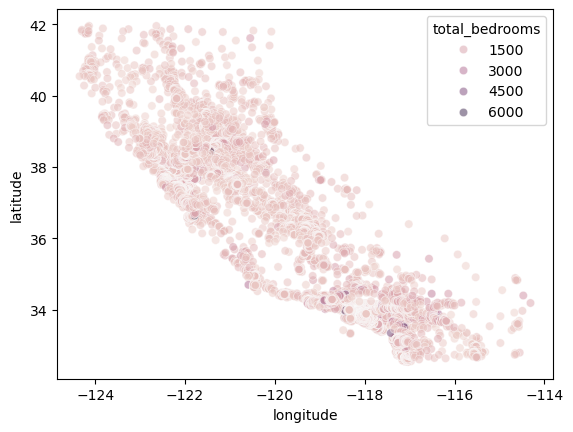

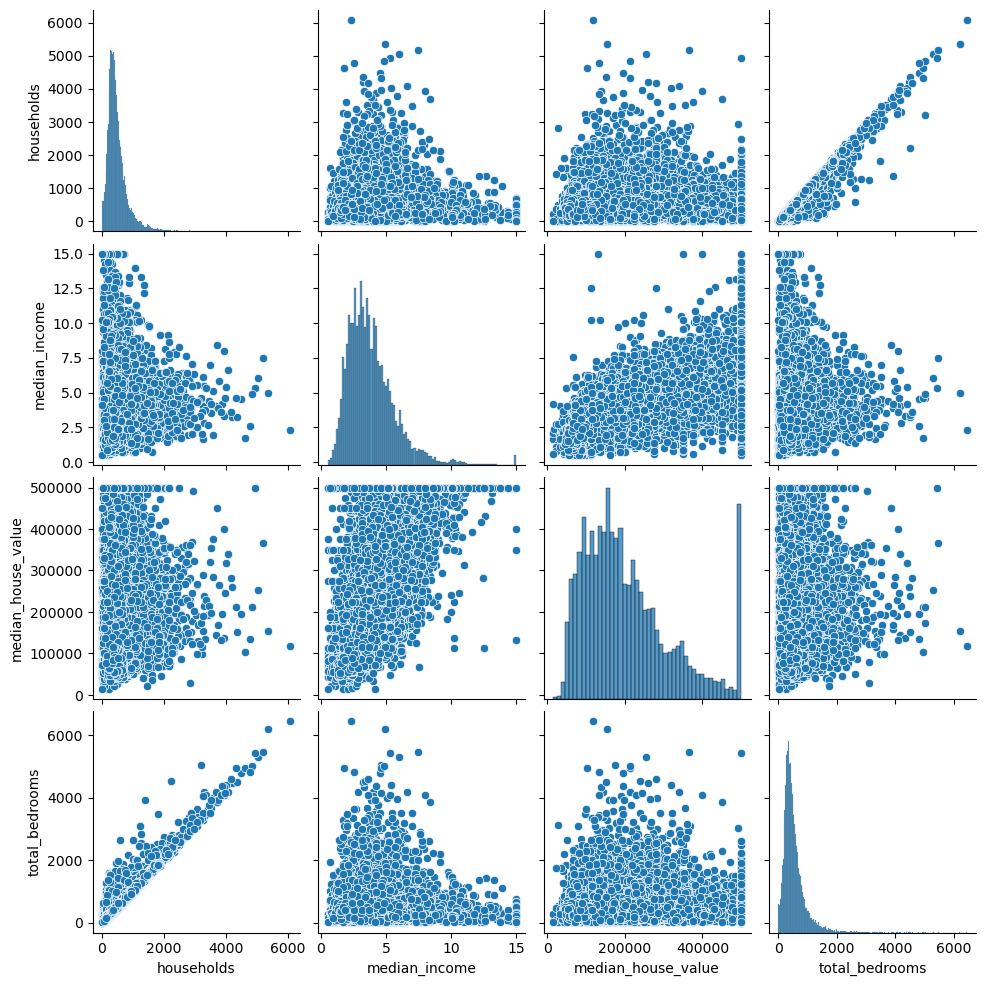

In [9]:
data_exploration(df)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

def prep_df (df, target_col):
    features = df.drop(columns=[target_col])
    target = df[target_col]
    #missing = features[miss]
    X_train, X_test, y_train, y_test = train_test_split(features, target, train_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test
   

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def feature_engine(X_train, X_test, numerical_cols, cat_col):
    

    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_pipeline, numerical_cols),
            ('cat', categorical_pipeline, cat_col)
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    return X_train_processed, X_test_processed

In [12]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
#import xgboost as xgb

def model_building():

    models = {
        'LinearRegression': LinearRegression(),
        'LassoRegression': Lasso(),
        'RidgeRegression': Ridge(),
        'ElasticNet': ElasticNet(),
        'RandomForest': RandomForestRegressor(),
        'DecisionTree': DecisionTreeRegressor(),
        #'XGBoost': xgb.XGBRegressor()
    }

    parameter_grid = {
        'LinearRegression': {},
        'LassoRegression': {'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000] },
        'RidgeRegression':{
            'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
            'solver' : ['auto', 'svd', 'cholesky', 'lsqr', 'sag'],
            'tol' : [1e-4, 1e-3, 1e-2],  # Convergence tolerance
            'max_iter' : [500, 1000, 5000], # Iteration limit
            },
        'ElasticNet': {
            'alpha': [0.001, 0.01, 0.1, 1],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        },
        'RandomForest': {
            'n_estimators' : [100, 200, 500],
            'max_depth' : [None, 10, 30],
            'min_samples_split' : [2, 5, 10]
        },
        'DecisionTree': {
            'max_depth' : [2, 4, 6, 8, 10],
            'random_state': [20, 30, 42]
        },
        #'XGBoost': {
            #'n_estimators' : [100, 200, 500],
            #'max_depth' : [3, 4, 5, 6, 7, 8, 9, 10],
            #'learning_rate' : [0.01, 0.1, 0.3],
            #'subsample' : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            #'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            #'lambda' : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            #'alpha' : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,]
        #}
    }
    return models, parameter_grid

In [13]:
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def predictions_model (models, parameter_grid, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models.items():
        print(f"\n Training {model_name}...")

        params = parameter_grid.get(model_name, {})

        grid = GridSearchCV(
            estimator=model,
            param_grid= params,
            scoring='neg_mean_squared_error',
            cv=5,
            n_jobs=-1,
            verbose=1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        pred = best_model.predict (X_test)

        mae = mean_absolute_error(y_test, pred)

        mse = mean_squared_error(y_test, pred)

        r2 = r2_score(y_test, pred)

        results[model_name] = {
            "best_params": grid.best_params_,
            "best_score": grid.best_score_,
            "mae": mae,
            "mse": mse,
            "r2score": r2,
            "best_model": best_model
        }
        print(f"✔ {model_name} done.")

    return results, best_model

In [14]:
# 1. Split the dataset
X_train, X_test, y_train, y_test = prep_df(df, target_col='median_house_value')

# 2. Preprocess
X_train_processed, X_test_processed = feature_engine(
    X_train, X_test,
    numerical_cols=['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'],
    cat_col=['ocean_proximity']
)

# 3. Build models + grids
models, parameter_grid = model_building()


results, best_model = predictions_model(
    models=models,
    parameter_grid = parameter_grid,
    X_train = X_train_processed,
    X_test=X_test_processed,
    y_train=y_train,
    y_test=y_test

)


 Training LinearRegression...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
✔ LinearRegression done.

 Training LassoRegression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✔ LassoRegression done.

 Training RidgeRegression...
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
✔ RidgeRegression done.

 Training ElasticNet...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✔ ElasticNet done.

 Training RandomForest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✔ RandomForest done.

 Training DecisionTree...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
✔ DecisionTree done.


In [15]:
df_results = pd.DataFrame(results).T
df_results

,best_params,best_score,mae,mse,r2score,best_model
LinearRegression,{},-5333408032.472219,49798.135873,4698013362.953018,0.646217,LinearRegression()
LassoRegression,{'alpha': 1000},-5285654250.94826,50469.873462,4819019016.128699,0.637105,Lasso(alpha=1000)
RidgeRegression,"{'alpha': 10, 'max_iter': 500, 'solver': 'lsqr...",-5304992959.616133,49931.245275,4727234969.898267,0.644017,"Ridge(alpha=10, max_iter=500, solver='lsqr', t..."
ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.7}",-5245064611.992803,50242.599733,4767497651.937293,0.640985,"ElasticNet(alpha=0.1, l1_ratio=0.7)"
RandomForest,"{'max_depth': 30, 'min_samples_split': 2, 'n_e...",-3414856428.770097,37144.933038,3011755809.318921,0.773201,"(DecisionTreeRegressor(max_depth=30, max_featu..."
DecisionTree,"{'max_depth': 6, 'random_state': 30}",-5223582294.361058,49968.799903,5202896553.390513,0.608197,"DecisionTreeRegressor(max_depth=6, random_stat..."


In [16]:
df_results.sort_values(by="mse", ascending=False)

,best_params,best_score,mae,mse,r2score,best_model
DecisionTree,"{'max_depth': 6, 'random_state': 30}",-5223582294.361058,49968.799903,5202896553.390513,0.608197,"DecisionTreeRegressor(max_depth=6, random_stat..."
LassoRegression,{'alpha': 1000},-5285654250.94826,50469.873462,4819019016.128699,0.637105,Lasso(alpha=1000)
ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.7}",-5245064611.992803,50242.599733,4767497651.937293,0.640985,"ElasticNet(alpha=0.1, l1_ratio=0.7)"
RidgeRegression,"{'alpha': 10, 'max_iter': 500, 'solver': 'lsqr...",-5304992959.616133,49931.245275,4727234969.898267,0.644017,"Ridge(alpha=10, max_iter=500, solver='lsqr', t..."
LinearRegression,{},-5333408032.472219,49798.135873,4698013362.953018,0.646217,LinearRegression()
RandomForest,"{'max_depth': 30, 'min_samples_split': 2, 'n_e...",-3414856428.770097,37144.933038,3011755809.318921,0.773201,"(DecisionTreeRegressor(max_depth=30, max_featu..."


In [18]:
import joblib

best_model_name = df_results['mse'].idxmin()

best_model = results[best_model_name]['best_model']
best_params = results[best_model_name]['best_params']

joblib.dump(best_model, f"{'best_model_name'}_best_model_name.joblib")
joblib.dump(best_params, f"{'best_model_name'}_best_param_name.joblib")

['best_model_name_best_param_name.joblib']

In [19]:
results.keys()

dict_keys(['LinearRegression', 'LassoRegression', 'RidgeRegression', 'ElasticNet', 'RandomForest', 'DecisionTree'])

In [20]:
results[best_model_name]

{'best_params': {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 500},
 'best_score': -3414856428.770097,
 'mae': 37144.93303835565,
 'mse': 3011755809.3189206,
 'r2score': 0.7732005086762708,
 'best_model': RandomForestRegressor(max_depth=30, n_estimators=500)}